In [1]:
import pathlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import t, ttest_ind

sys.path.insert(0, str(pathlib.Path.cwd().parents[0]))
import bgg

%matplotlib inline

In [2]:
repository_path = pathlib.Path.cwd().parents[2]
bgg_path = repository_path / "data" / "bgg"

In [3]:
bgg_games_data = pd.read_csv(bgg_path / "games.csv")
bgg_mechanics_data = pd.read_csv(bgg_path / "mechanics.csv")

# Hypothesis 5 - Large-group vs smaller-group cooperative ratings on BGG

## 5.1 Question and pre-registered test

**Question.** Among cooperative games on BGG, do large-group games (supporting 6 or more players) rate differently from smaller-group games (capping at 5 or fewer)?

- **$H_0$:** the mean `BayesAvgRating` of co-op games with `MaxPlayers >= 6` equals that of co-op games with `MaxPlayers <= 5`.
- **$H_1$:** the two means differ.

**Why this matters.** Volcano Rush targets 6-8 players, so the relevant BGG comparison group is large-group co-op games. If large-group co-op games rate systematically lower than smaller-group co-op games, that is a market signal that the player-count axis Volcano Rush operates on is harder to balance well, which would be an external validity check on the simulation-side player-count effect from Hypothesis 1.

**Data.** BGG only. A game qualifies as cooperative if `mechanics.csv` has `Cooperative Game == 1` or `Semi-Cooperative Game == 1`. Same `NumUserRatings >= 500` filter as Hypothesis 4. Partition the remaining games by `MaxPlayers >= 6` vs `MaxPlayers <= 5`.

**Test.** Two-sample Welch t-test on `BayesAvgRating`. Each group's standard deviation is reported descriptively as a side observation on whether one of the two categories is more polarizing (a wider spread means players disagree more on whether the games are good). Significance level $\alpha = 0.05$.

**Decision rule.** Reject $H_0$ if the p-value is below the Holm-corrected threshold.

## 5.2 Data preparation

Steps:

1. Strip BGG's column-name idiosyncrasies (colons, spaces, hyphens) so all columns become valid Python identifiers.
2. Merge games with mechanics on `BGGId`.
3. Restrict to cooperative-flavoured games (`CooperativeGame == 1` OR `SemiCooperativeGame == 1`) with `NumUserRatings >= 500`.
4. Partition the remaining games by `MaxPlayers >= 6`.

In [4]:
bgg_games_data.columns = bgg.reformat_columns(bgg_games_data.columns)
bgg_mechanics_data.columns = bgg.reformat_columns(bgg_mechanics_data.columns)

In [5]:
bgg_games_with_mechanics = bgg_games_data.merge(bgg_mechanics_data, on = "BGGId")

is_cooperative_flavour = (
    (bgg_games_with_mechanics["CooperativeGame"] == 1)
    | (bgg_games_with_mechanics["SemiCooperativeGame"] == 1)
)
has_reliable_rating = bgg_games_with_mechanics["NumUserRatings"] >= 500
cooperative_subset = bgg_games_with_mechanics.loc[is_cooperative_flavour & has_reliable_rating]

is_large_group = cooperative_subset["MaxPlayers"] >= 6

large_group_ratings = cooperative_subset.loc[is_large_group, "BayesAvgRating"]
small_group_ratings = cooperative_subset.loc[~is_large_group, "BayesAvgRating"]

print(f"Large-group co-op games (MaxPlayers >= 6, n):   {len(large_group_ratings)}")
print(f"Smaller-group co-op games (MaxPlayers <= 5, n): {len(small_group_ratings)}")

Large-group co-op games (MaxPlayers >= 6, n):   173
Smaller-group co-op games (MaxPlayers <= 5, n): 346


## 5.3 Per-group mean and 95% confidence interval

For each group, compute the mean `BayesAvgRating` and a 95% CI using the Student t-distribution. With both groups in the hundreds the t-distribution is essentially normal, but t-quantiles keep the CI valid if either sample shrinks. Each group's standard deviation is also reported alongside the mean - a wider spread on one side means that category is more polarizing.

In [6]:
def mean_with_ci(values, confidence = 0.95):
    sample_size = len(values)
    mean = values.mean()
    std_dev = values.std(ddof = 1)
    standard_error = std_dev / np.sqrt(sample_size)
    margin = t.ppf((1 + confidence) / 2, df = sample_size - 1) * standard_error
    return sample_size, mean, std_dev, mean - margin, mean + margin


large_n, large_mean, large_std, large_lower, large_upper = mean_with_ci(large_group_ratings)
small_n, small_mean, small_std, small_lower, small_upper = mean_with_ci(small_group_ratings)

group_summary = pd.DataFrame([
    {"group": "large group (MaxPlayers >= 6)", "n": large_n,
     "mean": large_mean, "std": large_std,
     "ci_lower": large_lower, "ci_upper": large_upper},
    {"group": "smaller group (MaxPlayers <= 5)", "n": small_n,
     "mean": small_mean, "std": small_std,
     "ci_lower": small_lower, "ci_upper": small_upper},
]).set_index("group")

overall_mean = pd.concat([large_group_ratings, small_group_ratings]).mean()

print(f"Overall mean BayesAvgRating: {overall_mean:.4f}")
group_summary

Overall mean BayesAvgRating: 6.3545


,n,mean,std,ci_lower,ci_upper
group,,,,,
large group (MaxPlayers >= 6),173,6.228126,0.468891,6.157760,6.298492
smaller group (MaxPlayers <= 5),346,6.417616,0.590891,6.355135,6.480096


**Chart.** Mean BayesAvgRating per group with 95% CI. The dashed line marks the overall mean across the union of both groups. A bar whose CI does not cross the dashed line sits significantly above or below the average at the 5% level.

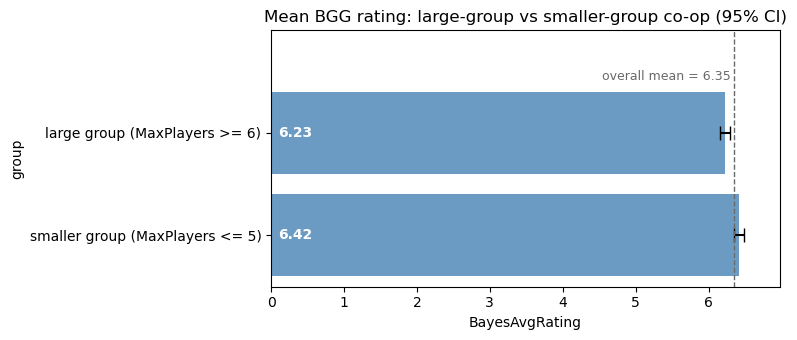

In [7]:
positions = np.arange(len(group_summary))
errors_lower = group_summary["mean"].values - group_summary["ci_lower"].values
errors_upper = group_summary["ci_upper"].values - group_summary["mean"].values

plt.figure(figsize = (8, 3.5))

plt.barh(positions, group_summary["mean"].values, color = "steelblue", alpha = 0.8)

plt.errorbar(group_summary["mean"].values, positions, xerr = [errors_lower, errors_upper],
             fmt = "none", color = "black", capsize = 5)

plt.axvline(overall_mean, color = "dimgray", linestyle = "--", linewidth = 1)
plt.text(overall_mean - 0.05, -0.55, f"overall mean = {overall_mean:.2f}",
         va = "center", ha = "right", fontsize = 9, color = "dimgray")

plt.yticks(positions, group_summary.index)
plt.xlabel("BayesAvgRating")
plt.ylabel("group")
plt.xlim(0, group_summary["ci_upper"].max() + 0.5)
plt.ylim(-1.0, len(group_summary) - 0.5)
plt.title("Mean BGG rating: large-group vs smaller-group co-op (95% CI)")

for i, mean_value in enumerate(group_summary["mean"].values):
    plt.text(0.1, i, f"{mean_value:.2f}", va = "center", ha = "left",
             color = "white", fontweight = "bold", fontsize = 10)
plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

**Distribution check.** The Welch t-test is robust to skew once each group has hundreds of observations (both groups here are well above), but it is still useful to eyeball whether the two populations have comparable shapes.

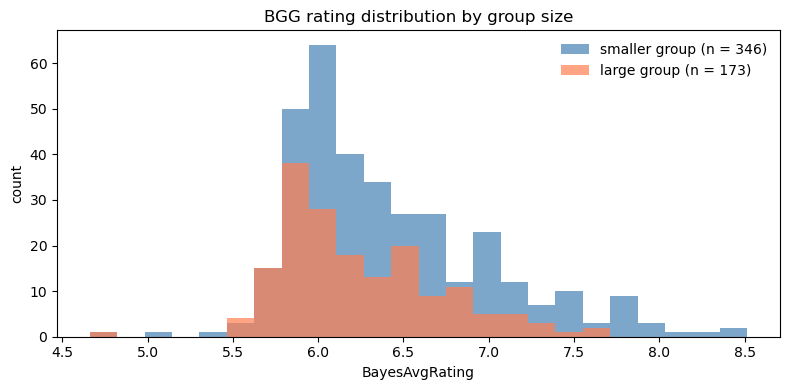

In [8]:
plt.figure(figsize = (8, 4))

bin_edges = np.linspace(
    min(large_group_ratings.min(), small_group_ratings.min()),
    max(large_group_ratings.max(), small_group_ratings.max()),
    25,
)

plt.hist(small_group_ratings, bins = bin_edges, color = "steelblue", alpha = 0.7,
         label = f"smaller group (n = {small_n})")
plt.hist(large_group_ratings, bins = bin_edges, color = "coral", alpha = 0.7,
         label = f"large group (n = {large_n})")

plt.xlabel("BayesAvgRating")
plt.ylabel("count")
plt.title("BGG rating distribution by group size")
plt.legend(frameon = False)

plt.tight_layout()

plt.show()

## 5.4 Welch's two-sample t-test

The Welch t-test does not assume equal variances between the two groups, which is the right primary test here - large-group and smaller-group cooperative populations have no a priori reason to share the same dispersion. The test is run two-sided since we have no directional prior.

In [9]:
welch_result = ttest_ind(large_group_ratings, small_group_ratings, equal_var = False)

print(f"t-statistic:        {welch_result.statistic:.4f}")
print(f"degrees of freedom: {welch_result.df:.1f}")
print(f"p-value:            {welch_result.pvalue:.4e}")

t-statistic:        -3.9684
degrees of freedom: 421.2
p-value:            8.5032e-05


## 5.5 Decision

The Welch t-test gives $t = -3.97$ on 421.2 degrees of freedom with $p = 8.5 \times 10^{-5}$, well below $\alpha = 0.05$. We **reject $H_0$** in favour of $H_1$: large-group cooperative games rate systematically lower than smaller-group cooperative games on BGG.

The observed mean ratings are 6.23 for large-group co-op (n = 173) and 6.42 for smaller-group co-op (n = 346) - large-group games sit about 0.19 BayesAvgRating points below smaller-group games. The two 95% CIs ([6.16, 6.30] vs [6.36, 6.48]) are disjoint, which confirms the difference at the 5% level independently of the t-test. The standard deviations are close (large-group ~0.46, smaller-group ~0.59), so the spread is comparable - the difference is in location, not in polarization.

**Implication for *Volcano Rush*.** VR is a 6-8 player co-op game, sitting squarely in the large-group bucket. The BGG signal is that this bucket carries a structural rating headwind: real designers in the large-group co-op space ship games that real players, on average, rate slightly lower than smaller-group co-op games. This is also a useful external-validity check on Hypothesis 1's player-count effect - the simulation showed a player-count imbalance inside Volcano Rush, and BGG shows the broader large-group co-op category is harder to land well in the first place. This should be flagged in the discussion section of the main notebook alongside the player-count and character-balance findings.